# Kosovo Healthcare Access Analyzer
**Author:** Anid Mehmeti 
**Institution:** RIT Kosovo  
**Date:** March 2026

## Project Overview
This notebook analyzes healthcare facility accessibility across Kosovo's 
municipalities using open data. The core metric is healthcare facilities 
per 1,000 residents, used to identify underserved regions.

## Data Sources
- Kosovo Agency of Statistics — municipal population data
- OpenStreetMap (Overpass Turbo) — healthcare facility locations
- GADM — Kosovo municipality shapefiles

In [34]:
# Standard data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Geospatial
import geopandas as gpd

# Utilities
import requests
import os

print("All libraries imported successfully.")

All libraries imported successfully.


## Step 2 - Data Collection
Data is collected from three sources: KAS (population), OpenStreetMap (facilities), and GADM (shapefiles).

In [35]:
# Load population data
# Skipping first 2 rows (title + blank), using only the first 2 columns
pop_df = pd.read_excel(
    '../data/raw/population_2024.xlsx',
    header=None,
    skiprows=3,
    usecols=[0, 1],
    names=['municipality', 'population']
)

# Drop the Kosovo total row and any rows with missing values
pop_df = pop_df.dropna()
pop_df = pop_df[pop_df['municipality'] != 'Kosova']

# Reset index cleanly
pop_df = pop_df.reset_index(drop=True)

print(f"Municipalities loaded: {len(pop_df)}")
print(pop_df.head(10))

Municipalities loaded: 38
   municipality  population
0         Deçan     27429.0
1       Gjakovë     77449.0
2       Gllogoc     47121.0
3        Gjilan     81842.0
4       Dragash     28637.0
5         Istog     32464.0
6       Kaçanik     27489.0
7         Klinë     29661.0
8  Fushë Kosovë     64393.0
9      Kamenicë     22312.0


### Healthcare Facility Data
- Source: OpenStreetMap via Overpass API
- Query: All nodes/ways tagged as healthcare facilities within Kosovo
- Returns: facility name, type, and coordinates (lat/lon)

In [36]:
# Query Overpass API for healthcare facilities in Kosovo
# amenity=clinic, hospital, doctors, pharmacy, dentist covers the main types

overpass_url = "http://overpass-api.de/api/interpreter"

overpass_query = """
[out:json][timeout:60];
area["name:en"="Kosovo"]->.searchArea;
(
  node["amenity"="hospital"](area.searchArea);
  node["amenity"="clinic"](area.searchArea);
  node["amenity"="doctors"](area.searchArea);
  node["amenity"="pharmacy"](area.searchArea);
  node["amenity"="dentist"](area.searchArea);
);
out body;
"""

response = requests.get(overpass_url, params={"data": overpass_query})
data = response.json()

print(f"Status code: {response.status_code}")
print(f"Facilities found: {len(data['elements'])}")

Status code: 200
Facilities found: 822


In [37]:
# Parse the API response into a DataFrame
# Each element in data['elements'] is a facility with tags and coordinates

facilities = []

for element in data['elements']:
    facilities.append({
        'facility_id': element.get('id'),
        'amenity_type': element.get('tags', {}).get('amenity'),
        'name': element.get('tags', {}).get('name', 'Unknown'),
        'lat': element.get('lat'),
        'lon': element.get('lon')
    })

facilities_df = pd.DataFrame(facilities)

print(f"Total facilities: {len(facilities_df)}")
print(f"\nFacility types breakdown:")
print(facilities_df['amenity_type'].value_counts())
print(f"\nSample rows:")
print(facilities_df.head())

Total facilities: 822

Facility types breakdown:
amenity_type
pharmacy    351
clinic      168
dentist     141
hospital     81
doctors      81
Name: count, dtype: int64

Sample rows:
   facility_id amenity_type                name        lat        lon
0    454697962     pharmacy              Humana  42.575866  21.579319
1    454704042     hospital       QKMF Kamenica  42.576347  21.580115
2    517589630     hospital  Klinika Kirurgjike  42.644364  21.162371
3    603647263      doctors            Ars Dent  42.668393  21.175257
4    612468828      doctors           Kirurgjia  42.657581  21.156246


### Data Decision: Healthcare Facility Types
**Included in primary care metric:** hospitals, clinics, doctors  
**Excluded:** pharmacies, dentists  

**Rationale:** Pharmacies dispense medication but do not provide diagnosis or 
treatment — a municipality with only pharmacies is still medically underserved. 
Dentists are excluded as they represent specialized rather than primary care.

**Note:** Pharmacy data is retained separately for potential secondary analysis 
(pharmacy-to-doctor ratio in underserved regions).

In [38]:

# Separate primary care facilities from the full dataset
primary_care_df = facilities_df[
    facilities_df['amenity_type'].isin(['hospital', 'clinic', 'doctors'])
].copy()

# Keep pharmacies separately for potential secondary analysis
pharmacy_df = facilities_df[
    facilities_df['amenity_type'] == 'pharmacy'
].copy()

print(f"Primary care facilities: {len(primary_care_df)}")
print(f"Pharmacies retained separately: {len(pharmacy_df)}")
print(f"\nBreakdown:")
print(primary_care_df['amenity_type'].value_counts())

Primary care facilities: 330
Pharmacies retained separately: 351

Breakdown:
amenity_type
clinic      168
hospital     81
doctors      81
Name: count, dtype: int64


In [39]:
# Save raw facility data to disk so we don't need to re-query the API
facilities_df.to_csv('../data/raw/facilities_all.csv', index=False)
primary_care_df.to_csv('../data/raw/facilities_primary_care.csv', index=False)
pharmacy_df.to_csv('../data/raw/facilities_pharmacy.csv', index=False)

print("Facility data saved to data/raw/")

Facility data saved to data/raw/


In [40]:
# Load Kosovo municipality boundaries
kosovo_map = gpd.read_file('../data/raw/gadm41_XKO_2.shp')

print(f"Shape of geodataframe: {kosovo_map.shape}")
print(f"\nColumns: {kosovo_map.columns.tolist()}")
print(f"\nSample municipality names:")
print(kosovo_map['NAME_2'].to_string())

Shape of geodataframe: (30, 14)

Columns: ['GID_2', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'NAME_2', 'VARNAME_2', 'NL_NAME_2', 'TYPE_2', 'ENGTYPE_2', 'CC_2', 'HASC_2', 'geometry']

Sample municipality names:
0               Đakovica
1                 Dečani
2               Orahovac
3               Gnjilane
4      Kosovska Kamenica
5                 Vitina
6     Kosovska Mitrovica
7              Leposavić
8                 Srbica
9                Vucitrn
10           Zubin Potok
11                Zvečan
12                 Istok
13                 Klina
14                   Peć
15              Glogovac
16          Kosovo Polje
17               Lipljan
18             Novo Brdo
19                Obilić
20              Podujevo
21              Priština
22                Dragaš
23              Mališevo
24               Prizren
25             Suva Reka
26               Kačanik
27               Štimlje
28                Štrpce
29              Uroševac


In [41]:
# Translate Serbian municipality names to Albanian
name_translation = {
    'Đakovica': 'Gjakovë',
    'Dečani': 'Deçan',
    'Orahovac': 'Rahovec',
    'Gnjilane': 'Gjilan',
    'Kosovska Kamenica': 'Kamenicë',
    'Vitina': 'Viti',
    'Kosovska Mitrovica': 'Mitrovicë',
    'Leposavić': 'Leposaviq',
    'Srbica': 'Sknderaj',
    'Vucitrn': 'Vushtrri',
    'Zubin Potok': 'Zubin Potok',
    'Zvečan': 'Zveçan',
    'Istok': 'Istog',
    'Klina': 'Klinë',
    'Peć': 'Pejë',
    'Glogovac': 'Gllogoc',
    'Kosovo Polje': 'Fushë Kosovë',
    'Lipljan': 'Lipjan',
    'Novo Brdo': 'Novobërdë',
    'Obilić': 'Obiliq',
    'Podujevo': 'Podujevë',
    'Priština': 'Prishtinë',
    'Dragaš': 'Dragash',
    'Mališevo': 'Malishevë',
    'Prizren': 'Prizren',
    'Suva Reka': 'Suharekë',
    'Kačanik': 'Kaçanik',
    'Štimlje': 'Shtime',
    'Štrpce': 'Shtërpcë',
    'Uroševac': 'Ferizaj'
}

# Apply translation
kosovo_map['municipality'] = kosovo_map['NAME_2'].map(name_translation)

# Now compare with population data to find missing municipalities
gadm_names = set(kosovo_map['municipality'])
kas_names = set(pop_df['municipality'])

missing_from_gadm = kas_names - gadm_names
missing_from_kas = gadm_names - kas_names

print("In KAS but missing from GADM shapefile:")
for name in sorted(missing_from_gadm):
    print(f"  - {name}")


In KAS but missing from GADM shapefile:
  - Graçanicë
  - Hani i Elezit
  - Junik
  - Kllokot
  - Mamushë
  - Mitrovica e V.
  - Partesh
  - Ranillug


In [42]:
missing = ['Graçanicë', 'Hani i Elezit', 'Junik', 'Kllokot', 
           'Mamushë', 'Mitrovica e V.', 'Partesh', 'Ranillug']

print(pop_df[pop_df['municipality'].isin(missing)][['municipality', 'population']])
print(f"\nTotal population in missing municipalities: {pop_df[pop_df['municipality'].isin(missing)]['population'].sum():.0f}")
print(f"As % of Kosovo total: {pop_df[pop_df['municipality'].isin(missing)]['population'].sum() / pop_df['population'].sum() * 100:.1f}%")

      municipality  population
30           Junik      3905.0
31         Mamushë      5636.0
32   Hani i Elezit      8555.0
33       Graçanicë     18592.0
34        Ranillug      2472.0
35         Partesh      3226.0
36         Kllokot      3019.0
37  Mitrovica e V.      7923.0

Total population in missing municipalities: 53328
As % of Kosovo total: 3.4%


### Data Decision: Excluded Municipalities
The following 8 municipalities are excluded from analysis due to missing 
GADM shapefile boundaries: Graçanicë, Hani i Elezit, Junik, Kllokot, 
Mamushë, Mitrovica e V., Partesh, Ranillug.

These represent 3.4% of Kosovo's population (53,328 residents).

**Rationale for exclusion rather than reassignment:**
Five of these are predominantly Serb municipalities (Ranillug, Partesh, 
Kllokot, Graçanicë, Mitrovica e V.) where residents may seek healthcare 
outside Kosovo's system entirely. Reassigning their population to neighboring 
municipalities would misrepresent both the geographic and political reality 
on the ground.

The remaining three (Hani i Elezit, Junik, and Mamushë) are excluded 
solely due to missing GADM shapefile boundary data, not for political reasons.

This is a known limitation of the analysis and should be considered by 
any policymaker reading these findings.

In [43]:
# Keep only municipalities present in both datasets
valid_municipalities = set(kosovo_map['municipality'])

pop_df_filtered = pop_df[
    pop_df['municipality'].isin(valid_municipalities)
].reset_index(drop=True)

print(f"Municipalities retained: {len(pop_df_filtered)}")
print(f"Municipalities excluded: {38 - len(pop_df_filtered)}")
print(f"\nPopulation covered: {pop_df_filtered['population'].sum():,.0f}")
print(f"As % of Kosovo total: {pop_df_filtered['population'].sum() / pop_df['population'].sum() * 100:.1f}%")

Municipalities retained: 30
Municipalities excluded: 8

Population covered: 1,532,262
As % of Kosovo total: 96.6%


In [44]:
# Save all processed data from Step 2
pop_df_filtered.to_csv('../data/processed/population_filtered.csv', index=False)
kosovo_map.to_file('../data/processed/kosovo_municipalities.gpkg', driver='GPKG')

print("Saved:")
print("  - data/processed/population_filtered.csv")
print("  - data/processed/kosovo_municipalities.gpkg")

Saved:
  - data/processed/population_filtered.csv
  - data/processed/kosovo_municipalities.gpkg


## Step 3 - Data Cleaning and Merging
Facilities are assigned to municipalities via spatial join using coordinates.
Final DataFrame contains population, facility count, and facilities-per-1000 ratio.

In [45]:
# Reload processed data
pop_df_filtered = pd.read_csv('../data/processed/population_filtered.csv')
kosovo_map = gpd.read_file('../data/processed/kosovo_municipalities.gpkg')
primary_care_df = pd.read_csv('../data/raw/facilities_primary_care.csv')

print(f"Population data: {len(pop_df_filtered)} municipalities")
print(f"Shapefile: {len(kosovo_map)} municipalities")
print(f"Facilities: {len(primary_care_df)} primary care facilities")

Population data: 30 municipalities
Shapefile: 30 municipalities
Facilities: 330 primary care facilities


In [46]:
# Convert facilities DataFrame to a GeoDataFrame
# This turns lat/lon columns into actual geometry points
facilities_gdf = gpd.GeoDataFrame(
    primary_care_df,
    geometry=gpd.points_from_xy(primary_care_df['lon'], primary_care_df['lat']),
    crs='EPSG:4326'  # Standard GPS coordinate system
)

# Make sure both layers use the same coordinate system
kosovo_map = kosovo_map.to_crs('EPSG:4326')

# Spatial join — assigns each facility to the municipality it falls within
facilities_joined = gpd.sjoin(
    facilities_gdf,
    kosovo_map[['municipality', 'geometry']],
    how='left',
    predicate='within'
)

print(f"Total facilities: {len(facilities_joined)}")
print(f"Facilities successfully assigned to a municipality: {facilities_joined['municipality'].notna().sum()}")
print(f"Facilities not assigned: {facilities_joined['municipality'].isna().sum()}")

Total facilities: 330
Facilities successfully assigned to a municipality: 329
Facilities not assigned: 1


In [47]:
# Drop the one unassigned facility
facilities_joined = facilities_joined.dropna(subset=['municipality'])

print(f"Facilities retained: {len(facilities_joined)}")

# Count facilities per municipality
facility_counts = facilities_joined.groupby('municipality').size().reset_index(name='facility_count')

print(f"\nMunicipalities with at least one facility: {len(facility_counts)}")
print(f"\nFacility counts sample:")
print(facility_counts.sort_values('facility_count', ascending=False).head(10))

Facilities retained: 329

Municipalities with at least one facility: 27

Facility counts sample:
   municipality  facility_count
18    Prishtinë             130
4       Gjakovë              38
19      Prizren              28
5        Gjilan              23
16         Pejë              20
9       Kaçanik              13
12       Lipjan              10
25     Vushtrri              10
23     Suharekë               8
2       Ferizaj               7


In [48]:
# Check Mitrovicë specifically
print("Mitrovicë in facility counts:")
print(facility_counts[facility_counts['municipality'] == 'Mitrovicë'])

# Find which municipalities have zero facilities
all_municipalities = set(pop_df_filtered['municipality'])
municipalities_with_facilities = set(facility_counts['municipality'])
zero_facilities = all_municipalities - municipalities_with_facilities

print(f"\nMunicipalities with zero facilities assigned: {len(zero_facilities)}")
for m in sorted(zero_facilities):
    print(f"  - {m}")

Mitrovicë in facility counts:
   municipality  facility_count
14    Mitrovicë               4

Municipalities with zero facilities assigned: 3
  - Novobërdë
  - Shtërpcë
  - Zubin Potok


In [49]:
# Full facility count breakdown sorted descending
print("All municipalities by facility count:")
print(facility_counts.sort_values('facility_count', ascending=False).to_string())

print("\nFacilities assigned to Mitrovicë:")
print(facilities_joined[facilities_joined['municipality'] == 'Mitrovicë'][['name', 'amenity_type', 'lat', 'lon']])

print("\nFacilities assigned to Prishtinë:")
print(facilities_joined[facilities_joined['municipality'] == 'Prishtinë'][['name', 'amenity_type', 'lat', 'lon']])

All municipalities by facility count:
    municipality  facility_count
18     Prishtinë             130
4        Gjakovë              38
19       Prizren              28
5         Gjilan              23
16          Pejë              20
9        Kaçanik              13
12        Lipjan              10
25      Vushtrri              10
23      Suharekë               8
2        Ferizaj               7
6        Gllogoc               5
7          Istog               4
3   Fushë Kosovë               4
14     Mitrovicë               4
1        Dragash               3
22      Sknderaj               3
17      Podujevë               3
0          Deçan               3
8       Kamenicë               2
10         Klinë               2
21        Shtime               2
13     Malishevë               2
11     Leposaviq               1
15        Obiliq               1
20       Rahovec               1
24          Viti               1
26        Zveçan               1

Facilities assigned to Mitrovicë:
   

In [50]:
# Find municipalities with zero facilities
all_municipalities = set(pop_df_filtered['municipality'])
municipalities_with_facilities = set(facility_counts['municipality'])
zero_facilities = all_municipalities - municipalities_with_facilities

print("Municipalities with zero recorded facilities:")
for m in sorted(zero_facilities):
    pop = pop_df_filtered[pop_df_filtered['municipality'] == m]['population'].values[0]
    print(f"  - {m}: population {pop:,.0f}")

Municipalities with zero recorded facilities:
  - Novobërdë: population 4,438
  - Shtërpcë: population 10,774
  - Zubin Potok: population 3,381


In [51]:
# Check ALL facility types for these municipalities (not just primary care)
all_facilities_gdf = gpd.GeoDataFrame(
    facilities_df,
    geometry=gpd.points_from_xy(facilities_df['lon'], facilities_df['lat']),
    crs='EPSG:4326'
)

all_joined = gpd.sjoin(
    all_facilities_gdf,
    kosovo_map[['municipality', 'geometry']],
    how='left',
    predicate='within'
)

zero_munis = ['Novobërdë', 'Shtërpcë', 'Zubin Potok']
for m in zero_munis:
    count = all_joined[all_joined['municipality'] == m]
    print(f"\n{m} — all facility types:")
    if len(count) == 0:
        print("  No facilities of any type recorded in OSM")
    else:
        print(count[['name', 'amenity_type']])


Novobërdë — all facility types:
  No facilities of any type recorded in OSM

Shtërpcë — all facility types:
  No facilities of any type recorded in OSM

Zubin Potok — all facility types:
  No facilities of any type recorded in OSM


In [52]:
missing_facilities = ['Novobërdë', 'Shtërpcë', 'Zubin Potok']

print(pop_df_filtered[
    pop_df_filtered['municipality'].isin(missing_facilities)
][['municipality', 'population']])

   municipality  population
13    Novobërdë      4438.0
22     Shtërpcë     10774.0
27  Zubin Potok      3381.0


### Data Decision: Municipalities with Zero OSM Facilities
Novobërdë, Shtërpcë, and Zubin Potok show zero facilities in OpenStreetMap.
These are predominantly Serb municipalities where OSM coverage is known to 
be incomplete — a zero here reflects a data gap, not reality.

Combined with the 5 Serb-majority municipalities excluded due to missing 
shapefile data, a total of 8 Serb-majority municipalities are absent from 
this analysis. Hani i Elezit, Junik, and Mamushë are excluded for shapefile 
reasons only.

These 3 municipalities are excluded from calculations. Final analysis 
covers 27 municipalities.

In [53]:
# Remove municipalities with zero OSM facilities
zero_facility_municipalities = ['Novobërdë', 'Shtërpcë', 'Zubin Potok']

pop_df_clean = pop_df_filtered[
    ~pop_df_filtered['municipality'].isin(zero_facility_municipalities)
].reset_index(drop=True)

kosovo_map_clean = kosovo_map[
    ~kosovo_map['municipality'].isin(zero_facility_municipalities)
].reset_index(drop=True)

print(f"Municipalities in final analysis: {len(pop_df_clean)}")
print(f"Population covered: {pop_df_clean['population'].sum():,.0f}")
print(f"As % of Kosovo total: {pop_df_clean['population'].sum() / pop_df['population'].sum() * 100:.1f}%")

Municipalities in final analysis: 27
Population covered: 1,513,669
As % of Kosovo total: 95.5%


In [54]:
# Merge population and facility counts into one DataFrame
merged_df = pop_df_clean.merge(facility_counts, on='municipality', how='left')

# Fill any remaining zeros (shouldn't be any, but just in case)
merged_df['facility_count'] = merged_df['facility_count'].fillna(0).astype(int)

# Calculate the core metric: facilities per 1000 residents
merged_df['facilities_per_1000'] = (
    merged_df['facility_count'] / merged_df['population'] * 1000
).round(3)

# Sort by facilities_per_1000 for easy reading
merged_df = merged_df.sort_values('facilities_per_1000', ascending=False).reset_index(drop=True)

print("Final merged DataFrame:")
print(merged_df.to_string())

Final merged DataFrame:
    municipality  population  facility_count  facilities_per_1000
0      Prishtinë    227737.0             130                0.571
1        Gjakovë     77449.0              38                0.491
2        Kaçanik     27489.0              13                0.473
3         Zveçan      2859.0               1                0.350
4         Gjilan     81842.0              23                0.281
5           Pejë     81751.0              20                0.245
6        Prizren    145938.0              28                0.192
7         Lipjan     54571.0              10                0.183
8       Suharekë     44690.0               8                0.179
9       Vushtrri     60658.0              10                0.165
10         Istog     32464.0               4                0.123
11         Deçan     27429.0               3                0.109
12       Gllogoc     47121.0               5                0.106
13       Dragash     28637.0               3        

In [55]:
# Save final merged DataFrame
merged_df.to_csv('../data/processed/final_merged.csv', index=False)

# Save cleaned shapefile
kosovo_map_clean.to_file('../data/processed/kosovo_map_clean.gpkg', driver='GPKG')

print("Saved:")
print("  - data/processed/final_merged.csv")
print("  - data/processed/kosovo_map_clean.gpkg")
print(f"\nFinal dataset: {len(merged_df)} municipalities")
print(f"Facilities range: {merged_df['facilities_per_1000'].min()} to {merged_df['facilities_per_1000'].max()}")
print(f"Mean facilities per 1000: {merged_df['facilities_per_1000'].mean():.3f}")

Saved:
  - data/processed/final_merged.csv
  - data/processed/kosovo_map_clean.gpkg

Final dataset: 27 municipalities
Facilities range: 0.025 to 0.571
Mean facilities per 1000: 0.162


### Analytical Note: Ratio Limitations
A high facilities-per-1000 ratio does not automatically indicate good healthcare 
access. Small municipalities with tiny populations can rank highly from even 
1-2 facilities. Absolute facility count and population size must be considered 
alongside the ratio when interpreting results.

## Step 4 - Analysis
Core metric baseline: 0.162 facilities per 1,000 residents (Kosovo mean).
Analysis examines underserved municipalities, urban/rural disparity, and regional patterns.

In [56]:
# Reload final merged data
merged_df = pd.read_csv('../data/processed/final_merged.csv')

# Define baseline
BASELINE = merged_df['facilities_per_1000'].mean()
print(f"Kosovo baseline: {BASELINE:.3f} facilities per 1,000 residents")

Kosovo baseline: 0.162 facilities per 1,000 residents


In [57]:
# Flag municipalities below the baseline
merged_df['underserved'] = merged_df['facilities_per_1000'] < BASELINE

underserved = merged_df[merged_df['underserved']].sort_values('facilities_per_1000')

print(f"Municipalities below baseline: {len(underserved)} out of {len(merged_df)}")
print(f"\nMost underserved municipalities:")
print(underserved[['municipality', 'population', 'facility_count', 'facilities_per_1000']].to_string())

Municipalities below baseline: 17 out of 27

Most underserved municipalities:
    municipality  population  facility_count  facilities_per_1000
26       Rahovec     40283.0               1                0.025
25          Viti     34898.0               1                0.029
24      Podujevë     69795.0               3                0.043
23        Obiliq     22729.0               1                0.044
22     Malishevë     42413.0               2                0.047
21     Mitrovicë     64201.0               4                0.062
20  Fushë Kosovë     64393.0               4                0.062
19       Ferizaj    108677.0               7                0.064
18         Klinë     29661.0               2                0.067
17      Sknderaj     40055.0               3                0.075
16        Shtime     24138.0               2                0.083
15      Kamenicë     22312.0               2                0.090
14     Leposaviq      9479.0               1                0.10

### Analytical Note: Private Clinic Underrepresentation
OSM data relies on community mapping contributions. Private clinics, which 
have grown significantly in Kosovo's larger cities, may be underrepresented. 
This could artificially lower facility counts for urban municipalities like 
Ferizaj and Mitrovica. Public/family medicine centers are likely more 
consistently mapped than private practices.

In [58]:
# Calculate total population living in underserved municipalities
underserved_population = underserved['population'].sum()
total_population = merged_df['population'].sum()

print(f"Total population in underserved municipalities: {underserved_population:,.0f}")
print(f"As % of analyzed population: {underserved_population / total_population * 100:.1f}%")

# Identify the most critical cases - bottom 5
print(f"\nThe 5 most underserved municipalities:")
print(underserved[['municipality', 'population', 'facilities_per_1000']].head())

Total population in underserved municipalities: 708,685
As % of analyzed population: 46.8%

The 5 most underserved municipalities:
   municipality  population  facilities_per_1000
26      Rahovec     40283.0                0.025
25         Viti     34898.0                0.029
24     Podujevë     69795.0                0.043
23       Obiliq     22729.0                0.044
22    Malishevë     42413.0                0.047


### Finding 1: Capital Concentration of Healthcare Investment
Prishtinë dominates with 130 facilities (0.571 per 1,000) while Ferizaj 
(108,677 residents) has only 7 facilities (0.064 per 1,000).

Post-war private investment concentrated in the capital due to economic 
incentives — proximity to government, international organizations, and 
higher-income populations. Secondary cities like Mitrovica and Ferizaj 
attracted significantly less private healthcare investment despite large 
populations.

46.8% of the analyzed population (708,685 residents) lives in municipalities 
below the 0.162 baseline — a stark indicator of systemic geographic inequality 
in healthcare distribution.

The planned UAE-funded regional hospital in Mitrovica represents a direct 
policy response to this documented gap.

In [59]:
# Define urban vs rural by population threshold
# Kosovo context: municipalities above 50,000 considered urban
URBAN_THRESHOLD = 50000

merged_df['urban_rural'] = merged_df['population'].apply(
    lambda x: 'Urban' if x >= URBAN_THRESHOLD else 'Rural'
)

# Compare average facilities per 1000 between urban and rural
disparity = merged_df.groupby('urban_rural').agg(
    municipality_count=('municipality', 'count'),
    avg_facilities_per_1000=('facilities_per_1000', 'mean'),
    total_population=('population', 'sum'),
    median_facilities_per_1000=('facilities_per_1000', 'median')
).round(3)

print(disparity)
print(f"\nUrban municipalities:")
print(merged_df[merged_df['urban_rural'] == 'Urban'][['municipality', 'population', 'facilities_per_1000']])
print(f"\nRural municipalities:")
print(merged_df[merged_df['urban_rural'] == 'Rural'][['municipality', 'population', 'facilities_per_1000']])

             municipality_count  avg_facilities_per_1000  total_population  \
urban_rural                                                                  
Rural                        16                    0.126          476657.0   
Urban                        11                    0.214         1037012.0   

             median_facilities_per_1000  
urban_rural                              
Rural                             0.098  
Urban                             0.183  

Urban municipalities:
    municipality  population  facilities_per_1000
0      Prishtinë    227737.0                0.571
1        Gjakovë     77449.0                0.491
4         Gjilan     81842.0                0.281
5           Pejë     81751.0                0.245
6        Prizren    145938.0                0.192
7         Lipjan     54571.0                0.183
9       Vushtrri     60658.0                0.165
19       Ferizaj    108677.0                0.064
20  Fushë Kosovë     64393.0                0.

In [60]:
# Urban average with and without Prishtinë
urban_df = merged_df[merged_df['urban_rural'] == 'Urban']

with_capital = urban_df['facilities_per_1000'].mean()
without_capital = urban_df[urban_df['municipality'] != 'Prishtinë']['facilities_per_1000'].mean()

print(f"Urban average with Prishtinë: {with_capital:.3f}")
print(f"Urban average without Prishtinë: {without_capital:.3f}")
print(f"Rural average: {merged_df[merged_df['urban_rural'] == 'Rural']['facilities_per_1000'].mean():.3f}")

Urban average with Prishtinë: 0.214
Urban average without Prishtinë: 0.179
Rural average: 0.126


### Finding 2: The "Prishtina Black Hole" Effect
Simple urban/rural analysis shows urban municipalities average 0.214 vs 
rural 0.126 — but this is misleading. Without Prishtinë, urban average 
drops to 0.179, barely above baseline.

The real pattern is geographic proximity to Prishtinë:
- Cities near Prishtinë (Ferizaj, Fushë Kosovë, Podujevë, Mitrovicë) 
  are among the most underserved despite being urban — investors and 
  residents both gravitate toward the capital, leaving these cities 
  without sufficient local healthcare infrastructure.
- Western cities (Gjakovë, Pejë, Prizren) rank significantly higher 
  because geographic distance from Prishtinë forced independent 
  healthcare development.

The urban/rural divide is less explanatory than a capital-proximity divide.

In [61]:
# Calculate gap from baseline for each municipality
merged_df['gap_from_baseline'] = (
    merged_df['facilities_per_1000'] - BASELINE
).round(3)

# Classify into coverage tiers
def coverage_tier(ratio):
    if ratio >= BASELINE * 1.5:
        return 'Well Served'
    elif ratio >= BASELINE:
        return 'Adequately Served'
    elif ratio >= BASELINE * 0.5:
        return 'Underserved'
    else:
        return 'Critically Underserved'

merged_df['coverage_tier'] = merged_df['facilities_per_1000'].apply(coverage_tier)

# Summary by tier
print("Coverage tier summary:")
print(merged_df.groupby('coverage_tier').agg(
    municipalities=('municipality', 'count'),
    total_population=('population', 'sum'),
    avg_ratio=('facilities_per_1000', 'mean')
).round(3))

print(f"\nCritically underserved municipalities:")
critical = merged_df[merged_df['coverage_tier'] == 'Critically Underserved']
print(critical[['municipality', 'population', 'facilities_per_1000', 'gap_from_baseline']])

Coverage tier summary:
                        municipalities  total_population  avg_ratio
coverage_tier                                                      
Adequately Served                    4          305857.0      0.180
Critically Underserved              10          517105.0      0.052
Underserved                          7          191580.0      0.103
Well Served                          6          499127.0      0.402

Critically underserved municipalities:
    municipality  population  facilities_per_1000  gap_from_baseline
17      Sknderaj     40055.0                0.075             -0.087
18         Klinë     29661.0                0.067             -0.095
19       Ferizaj    108677.0                0.064             -0.098
20  Fushë Kosovë     64393.0                0.062             -0.100
21     Mitrovicë     64201.0                0.062             -0.100
22     Malishevë     42413.0                0.047             -0.115
23        Obiliq     22729.0                0.

## Step 5 - Visualizations
Four visualizations communicating healthcare access patterns across Kosovo's municipalities.

In [62]:
# Reload analyzed data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

merged_df = pd.read_csv('../data/processed/analyzed_data.csv')
kosovo_map_clean = gpd.read_file('../data/processed/kosovo_map_clean.gpkg')

# Define consistent color palette for coverage tiers
tier_colors = {
    'Well Served': '#2ecc71',        # green
    'Adequately Served': '#f39c12',  # orange
    'Underserved': '#e67e22',        # dark orange
    'Critically Underserved': '#e74c3c'  # red
}

# Define tier order for consistent sorting
tier_order = ['Well Served', 'Adequately Served', 'Underserved', 'Critically Underserved']

print("Data loaded and color palette defined.")
print(merged_df['coverage_tier'].value_counts())

Data loaded and color palette defined.
coverage_tier
Critically Underserved    10
Underserved                7
Well Served                6
Adequately Served          4
Name: count, dtype: int64


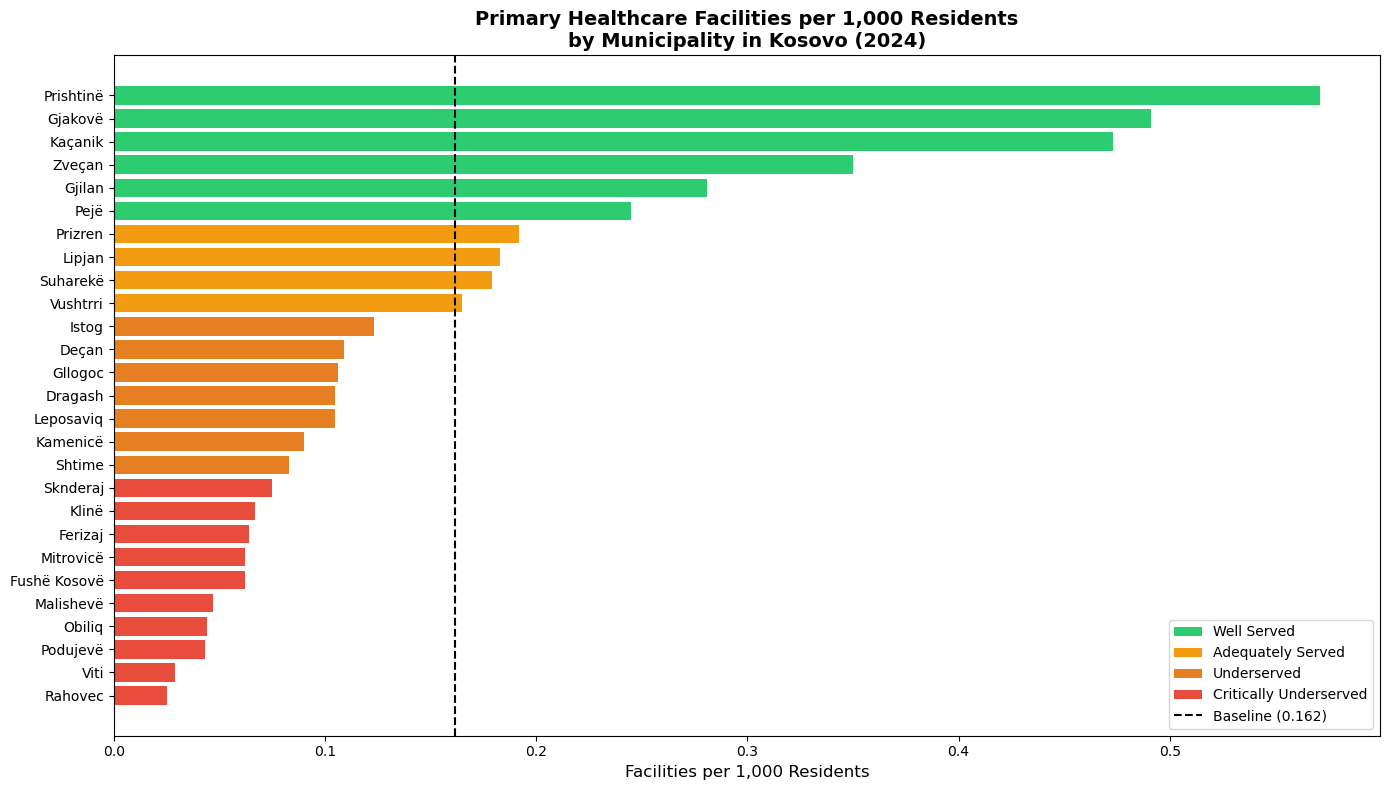

Saved: outputs/01_bar_chart.png


In [63]:
BASELINE = merged_df['facilities_per_1000'].mean()

# Visualization 1 — Bar chart: facilities per 1,000 by municipality
fig, ax = plt.subplots(figsize=(14, 8))

# Sort by facilities_per_1000 descending
plot_df = merged_df.sort_values('facilities_per_1000', ascending=True)

# Assign colors based on coverage tier
colors = [tier_colors[tier] for tier in plot_df['coverage_tier']]

# Plot horizontal bars
ax.barh(plot_df['municipality'], plot_df['facilities_per_1000'], color=colors)

# Add baseline reference line
ax.axvline(x=BASELINE, color='black', linestyle='--', linewidth=1.5, label=f'Kosovo Baseline ({BASELINE:.3f})')

# Labels and formatting
ax.set_xlabel('Facilities per 1,000 Residents', fontsize=12)
ax.set_title('Primary Healthcare Facilities per 1,000 Residents\nby Municipality in Kosovo (2024)', fontsize=14, fontweight='bold')

# Add legend for tiers
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=tier_colors[t], label=t) for t in tier_order]
legend_elements.append(plt.Line2D([0], [0], color='black', linestyle='--', label=f'Baseline ({BASELINE:.3f})'))
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/01_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/01_bar_chart.png")

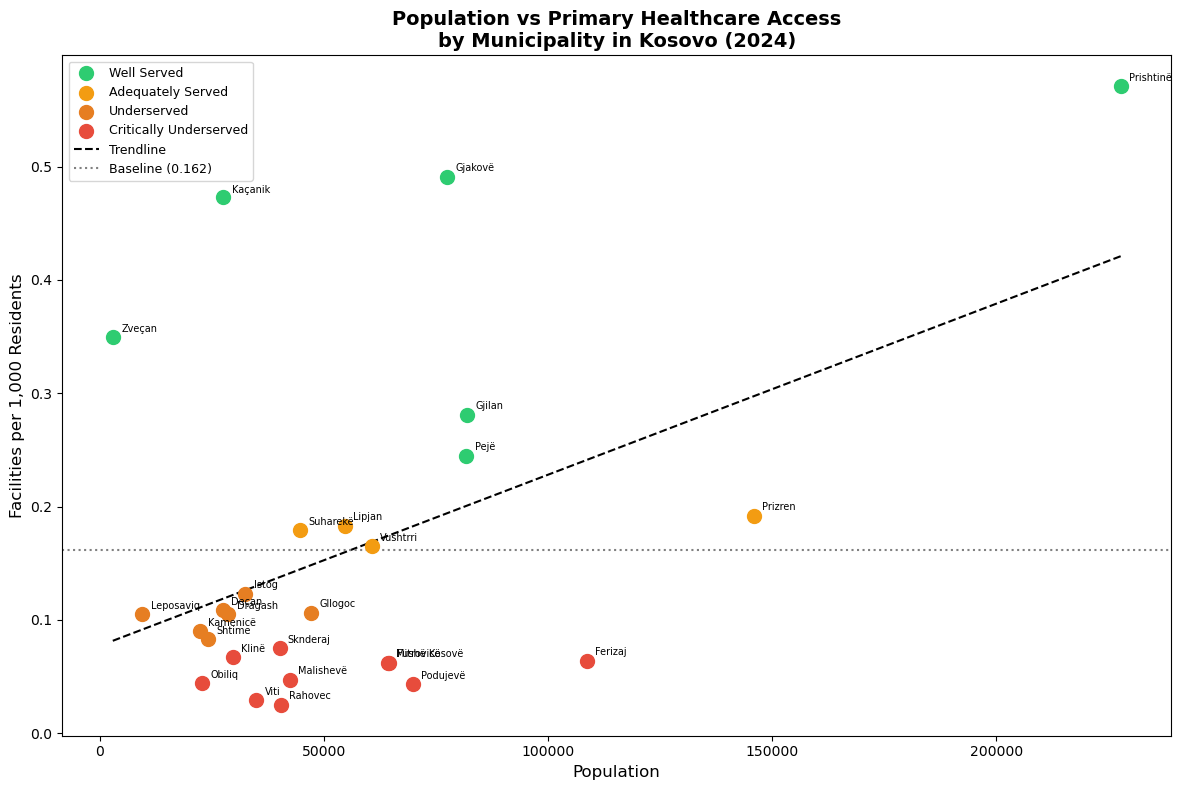

Saved: outputs/02_scatter_plot.png


In [64]:
# Visualization 2 — Scatter plot: population vs facilities per 1,000
fig, ax = plt.subplots(figsize=(12, 8))

# Plot each municipality as a point colored by tier
for tier in tier_order:
    subset = merged_df[merged_df['coverage_tier'] == tier]
    ax.scatter(
        subset['population'],
        subset['facilities_per_1000'],
        color=tier_colors[tier],
        label=tier,
        s=100,
        zorder=3
    )

# Add trendline
z = np.polyfit(merged_df['population'], merged_df['facilities_per_1000'], 1)
p = np.poly1d(z)
x_line = np.linspace(merged_df['population'].min(), merged_df['population'].max(), 100)
ax.plot(x_line, p(x_line), color='black', linestyle='--', linewidth=1.5, label='Trendline')

# Add baseline
ax.axhline(y=BASELINE, color='gray', linestyle=':', linewidth=1.5, label=f'Baseline ({BASELINE:.3f})')

# Label each point with municipality name
for _, row in merged_df.iterrows():
    ax.annotate(
        row['municipality'],
        (row['population'], row['facilities_per_1000']),
        textcoords='offset points',
        xytext=(6, 4),
        fontsize=7
    )

# Formatting
ax.set_xlabel('Population', fontsize=12)
ax.set_ylabel('Facilities per 1,000 Residents', fontsize=12)
ax.set_title('Population vs Primary Healthcare Access\nby Municipality in Kosovo (2024)', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/02_scatter_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/02_scatter_plot.png")

### Visualization Note: Scatter Plot Trendline
The upward trendline suggests larger populations correlate with better 
healthcare access. However this is largely driven by Prishtinë as an outlier.
Municipalities near Prishtinë (Ferizaj, Mitrovicë, Podujevë) sit well below 
the trendline despite large populations — consistent with the capital 
proximity effect identified in Step 4.
The trendline should be interpreted with caution.

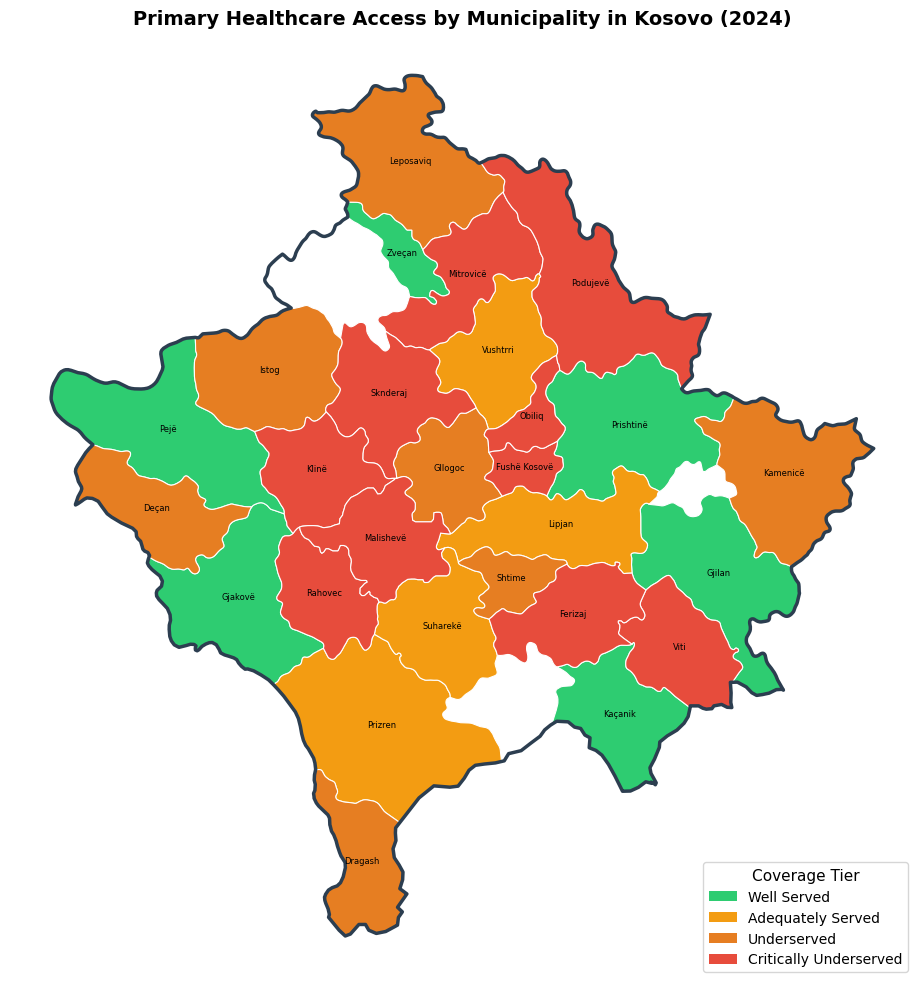

Saved: outputs/03_choropleth_map.png


In [65]:
# Visualization 3 — Choropleth map of Kosovo
# Merge analyzed data with shapefile
map_df = kosovo_map_clean.merge(merged_df[['municipality', 'facilities_per_1000', 'coverage_tier']], 
                                 on='municipality', how='left')

# Assign numeric tier order for coloring
tier_order_map = {
    'Well Served': 3,
    'Adequately Served': 2,
    'Underserved': 1,
    'Critically Underserved': 0
}
map_df['tier_numeric'] = map_df['coverage_tier'].map(tier_order_map)

fig, ax = plt.subplots(figsize=(14, 10))

# Plot each tier separately to control colors
for tier, color in tier_colors.items():
    subset = map_df[map_df['coverage_tier'] == tier]
    subset.plot(ax=ax, color=color, edgecolor='white', linewidth=0.8, label=tier)

    # Add Kosovo outer border
kosovo_border = kosovo_map.dissolve()
kosovo_border.plot(ax=ax, facecolor='none', edgecolor='#2c3e50', linewidth=2.5)

# Add municipality name labels
for _, row in map_df.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        row['municipality'],
        xy=(centroid.x, centroid.y),
        fontsize=6,
        ha='center',
        color='black'
    )

# Formatting
ax.set_title('Primary Healthcare Access by Municipality in Kosovo (2024)', 
             fontsize=14, fontweight='bold')
ax.set_axis_off()

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=tier_colors[t], label=t) for t in tier_order]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10, 
          title='Coverage Tier', title_fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/03_choropleth_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/03_choropleth_map.png")

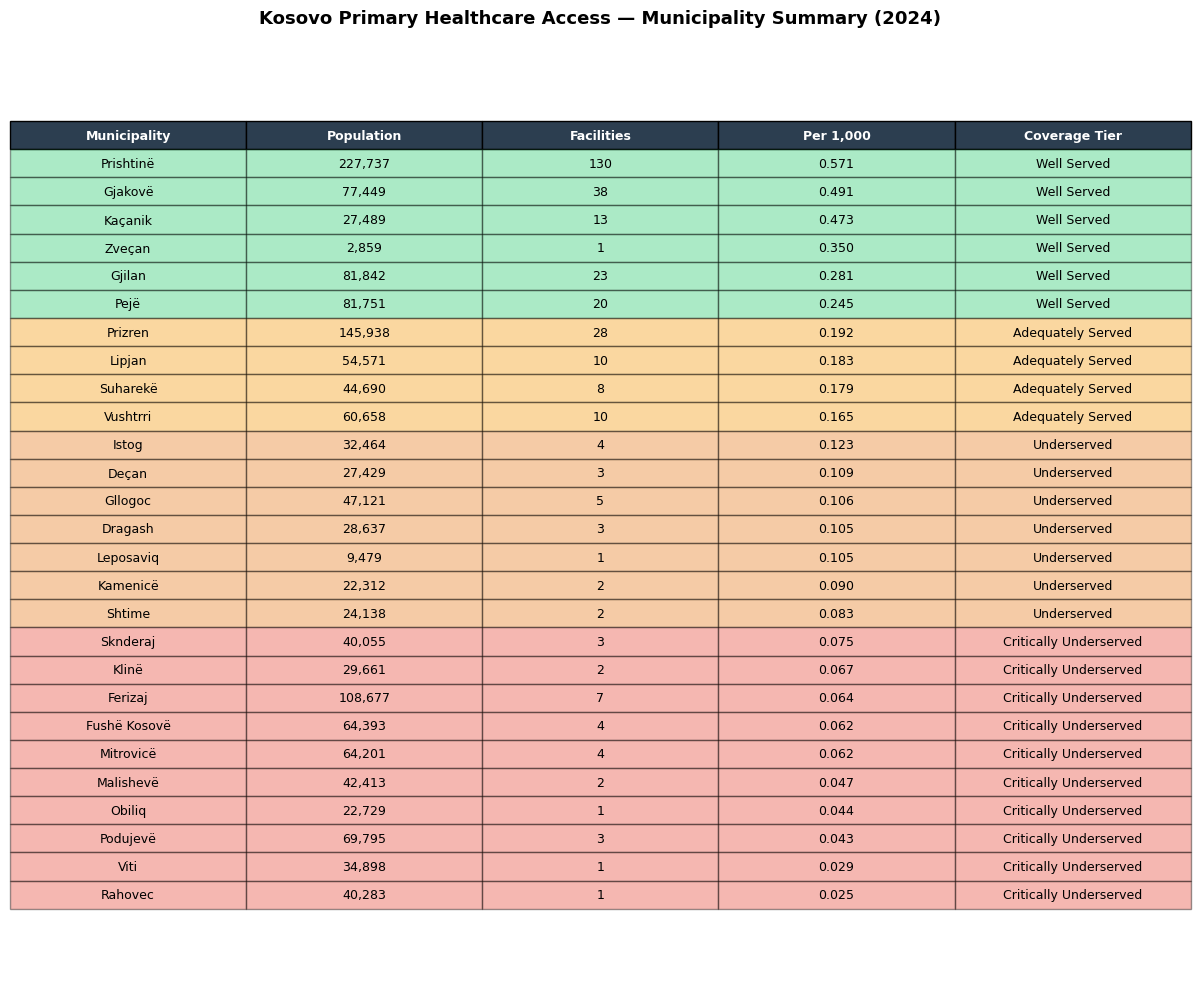

Saved: outputs/04_summary_table.png


In [66]:
# Visualization 4 — Summary table
fig, ax = plt.subplots(figsize=(12, 10))
ax.set_axis_off()

# Prepare table data
table_df = merged_df[['municipality', 'population', 'facility_count', 
                       'facilities_per_1000', 'coverage_tier']].copy()
table_df = table_df.sort_values('facilities_per_1000', ascending=False)
table_df['population'] = table_df['population'].astype(int).apply(lambda x: f"{x:,}")
table_df['facilities_per_1000'] = table_df['facilities_per_1000'].apply(lambda x: f"{x:.3f}")
table_df.columns = ['Municipality', 'Population', 'Facilities', 
                    'Per 1,000', 'Coverage Tier']

# Draw table
table = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.4)

# Color rows by coverage tier
tier_col_index = 4
for i, (_, row) in enumerate(table_df.iterrows()):
    tier = row['Coverage Tier']
    color = tier_colors[tier]
    for j in range(len(table_df.columns)):
        table[i + 1, j].set_facecolor(color)
        table[i + 1, j].set_alpha(0.4)

# Header styling
for j in range(len(table_df.columns)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

ax.set_title('Kosovo Primary Healthcare Access — Municipality Summary (2024)',
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('../outputs/04_summary_table.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/04_summary_table.png")